In [1]:
import micropip
await micropip.install("seaborn")
await micropip.install("scikit-learn")

Dataset Loaded Successfully!

   age  gender    country  daily_usage_hours primary_platform  \
0   19    Male  Australia           2.658617         Snapchat   
1   16  Female        USA           5.685387          Twitter   
2   25  Female      India           2.782420           TikTok   
3   27    Male      India           3.486598          YouTube   
4   23  Female      India           3.748829           TikTok   

   num_platforms_used        purpose  avg_session_minutes  night_usage  \
0                   4      Education            29.222443            0   
1                   3    Socializing            32.464726            1   
2                   2    Socializing            18.170204            1   
3                   4      Education            22.493804            1   
4                   1  Entertainment            27.358410            1   

   mental_health_score addiction_level  screen_time_before_sleep  
0             6.705830          Medium                 15.779443  


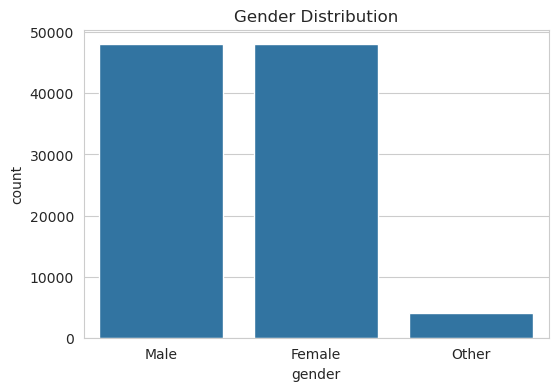

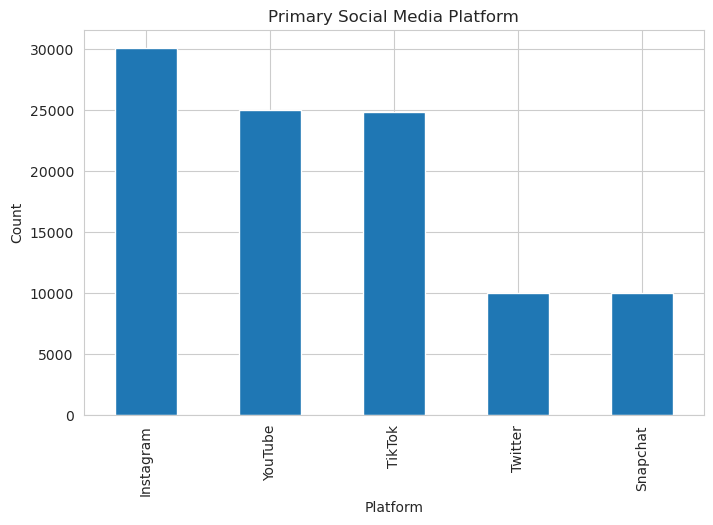

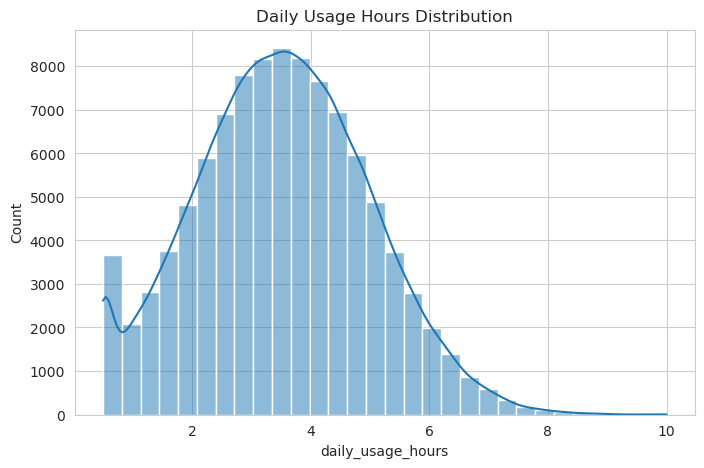

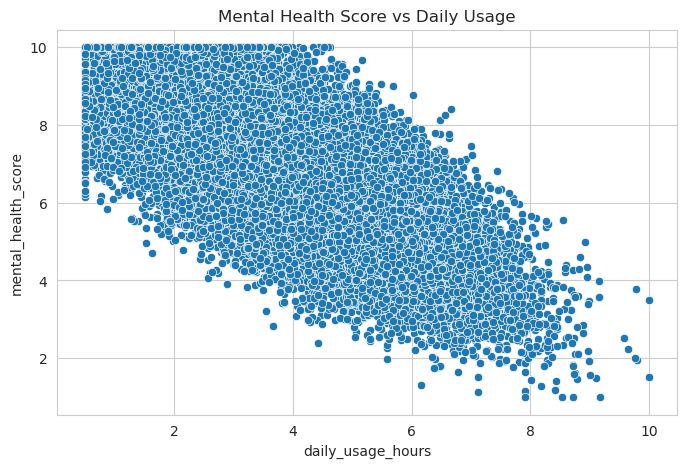

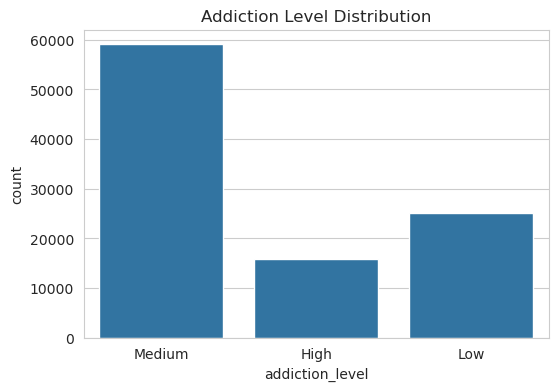

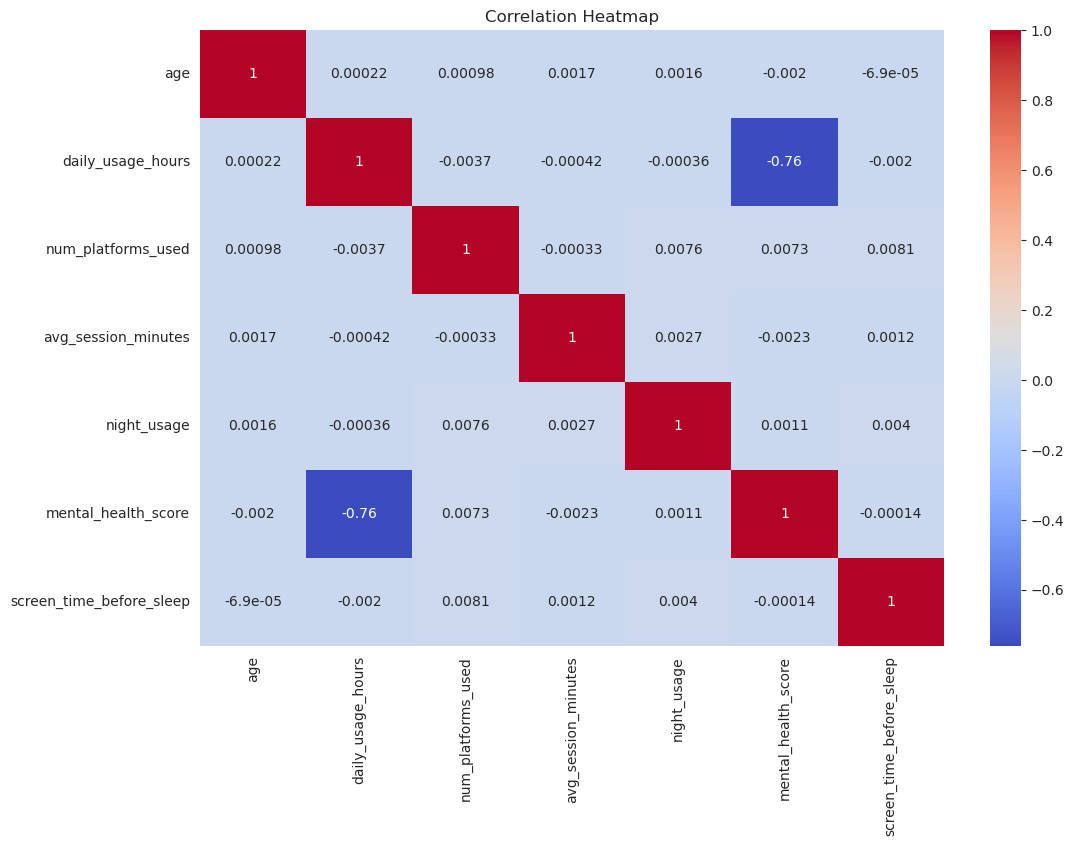


Model Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3154
           1       1.00      1.00      1.00      4975
           2       1.00      1.00      1.00     11871

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



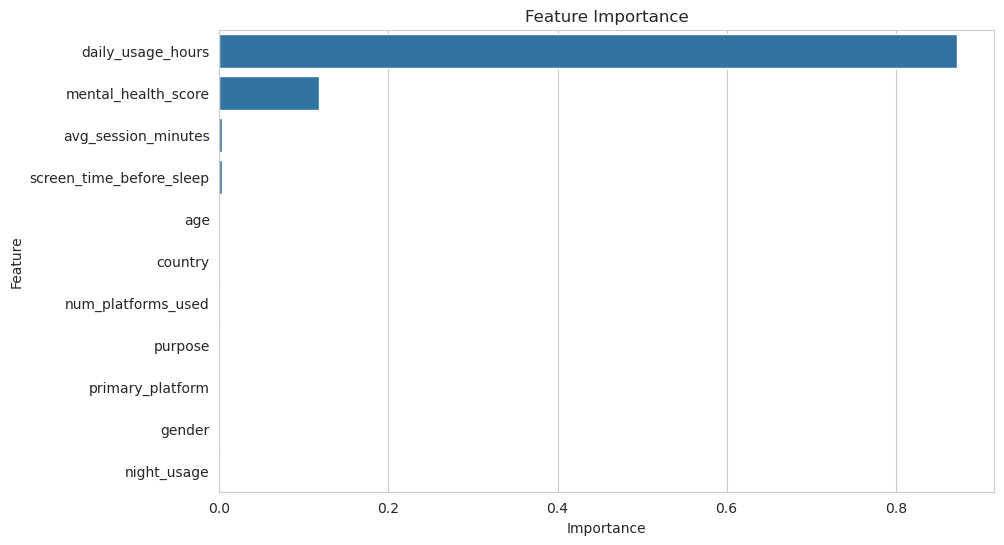


Cleaned dataset saved successfully!

Project Conclusion

1. The dataset helps analyze Gen Z social media behavior.
2. Social media usage affects addiction levels.
3. Different platforms are preferred by users.
4. Machine learning predicts addiction levels effectively.
5. Visualization provides clear insights into user behavior.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


df = pd.read_csv("genz_dataset_under25mb.csv")

print("Dataset Loaded Successfully!\n")

print(df.head())

print("\nDataset Shape:")
print(df.shape)


print("\nColumns:")
print(df.columns)


print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

sns.set_style("whitegrid")


plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()


plt.figure(figsize=(8,5))
df['primary_platform'].value_counts().plot(kind='bar')
plt.title("Primary Social Media Platform")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(df['daily_usage_hours'], bins=30, kde=True)
plt.title("Daily Usage Hours Distribution")
plt.show()


plt.figure(figsize=(8,5))
sns.scatterplot(
    x='daily_usage_hours',
    y='mental_health_score',
    data=df
)
plt.title("Mental Health Score vs Daily Usage")
plt.show()


plt.figure(figsize=(6,4))
sns.countplot(x='addiction_level', data=df)
plt.title("Addiction Level Distribution")
plt.show()


numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()


ml_df = df.copy()

for col in ml_df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(
        ml_df[col].astype(str)
    )

X = ml_df.drop("addiction_level", axis=1)
y = ml_df["addiction_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nModel Accuracy:")
print(accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.show()

df.to_csv(
    "cleaned_genz_dataset.csv",
    index=False
)

print("\nCleaned dataset saved successfully!")
print("""
Project Conclusion

1. The dataset helps analyze Gen Z social media behavior.
2. Social media usage affects addiction levels.
3. Different platforms are preferred by users.
4. Machine learning predicts addiction levels effectively.
5. Visualization provides clear insights into user behavior.
""")